# **Time Series Analysis of Credit Card Customer Behavior for Credit Risk Assessment and Attrition Prediction:**

# **About the Author:**

**Name: Adil Zaman**

**Email ID: zamanadil61@gmail.com**

**Kaggle ID: https://www.kaggle.com/zemnukes98**

**Github ID: https://github.com/AdilZaman98**

**Linkedin ID: https://www.linkedin.com/in/adil-zaman-85b56a398/**

# **Behavioral and Temporal Analysis of Credit Card Customers for Credit Risk and Attrition Prediction:**

>**The BankChurners Dataset provides comprehensive information about credit card customers, including demographic characteristics, credit relationship details, and transaction behavior over time. It contains variables such as customer age, income category, credit limit, transaction amounts, utilization ratios, and inactivity periods, which collectively help analyze financial activity patterns and customer engagement with the bank. Temporal indicators like quarterly transaction changes and 12-month activity trends allow researchers to examine behavioral dynamics and identify signals related to credit risk and customer attrition. Consequently, the dataset serves as an important resource for applying statistical and machine learning techniques to understand evolving customer behavior and to support predictive modeling for credit risk assessment and customer retention strategies.**

# **Temporal Analysis of Credit Card Customer Behavior for Credit Risk and Attrition Prediction:**

>**The study applies time series analysis to examine how credit card customers’ transaction patterns, credit utilization, and inactivity trends evolve over time. By analyzing these temporal behavioral indicators, the research aims to identify early signals of credit risk and predict potential customer attrition. This approach helps financial institutions improve risk management and develop proactive customer retention strategies.**

**Now firstly preform Exploratory Data Analysis (EDA) of the dataset;**

# **Exploratory Data Analysis (EDA):**

In [22]:
#Let's start the project by importing all the libraries for that particular dataset
import pandas as pd
import numpy as np
# To visualize the dataset
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# To preprocess the dataset
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,MinMaxScaler,RobustScaler,PowerTransformer
from sklearn.impute import SimpleImputer,KNNImputer
# to import the iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
# for machine learning tasks
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
# for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# for regression tasks
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
#For Time series
from statsmodels.tsa.arima.model import ARIMA
# for metrics
from sklearn.metrics import accuracy_score, roc_auc_score,classification_report
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

**Now to load the dataset;**

# **Load the Dataset:**

In [7]:
df=pd.read_csv('BankChurners.csv')
df

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


**Now to see the Sneak-Peak of the dataset;**

# **Sneak-Peak of the dataset:**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [8]:
df.shape

(10127, 23)

**Here we see that their were 10127 rows and 23 columns in a dataset.**

In [9]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [10]:
df.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189,0.996620,0.003377


In [11]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


**Now to see the duplicates in the dataset;**

In [13]:
# Count duplicate rows
duplicates = df.duplicated().sum()
print("Total duplicate rows:", duplicates)
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)
df = df.drop_duplicates()
print("Duplicates removed. New shape:", df.shape)

Total duplicate rows: 0
Empty DataFrame
Columns: [CLIENTNUM, Attrition_Flag, Customer_Age, Gender, Dependent_count, Education_Level, Marital_Status, Income_Category, Card_Category, Months_on_book, Total_Relationship_Count, Months_Inactive_12_mon, Contacts_Count_12_mon, Credit_Limit, Total_Revolving_Bal, Avg_Open_To_Buy, Total_Amt_Chng_Q4_Q1, Total_Trans_Amt, Total_Trans_Ct, Total_Ct_Chng_Q4_Q1, Avg_Utilization_Ratio, Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1, Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2]
Index: []

[0 rows x 23 columns]
Duplicates removed. New shape: (10127, 23)


**Now to check the imputations in the dataset;**

# **Imputations in the dataset:**

In [14]:
df.isnull().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

**Here we see that their is no missing value in a dataset.**

**Now to view the imputations which indicates the above result;**

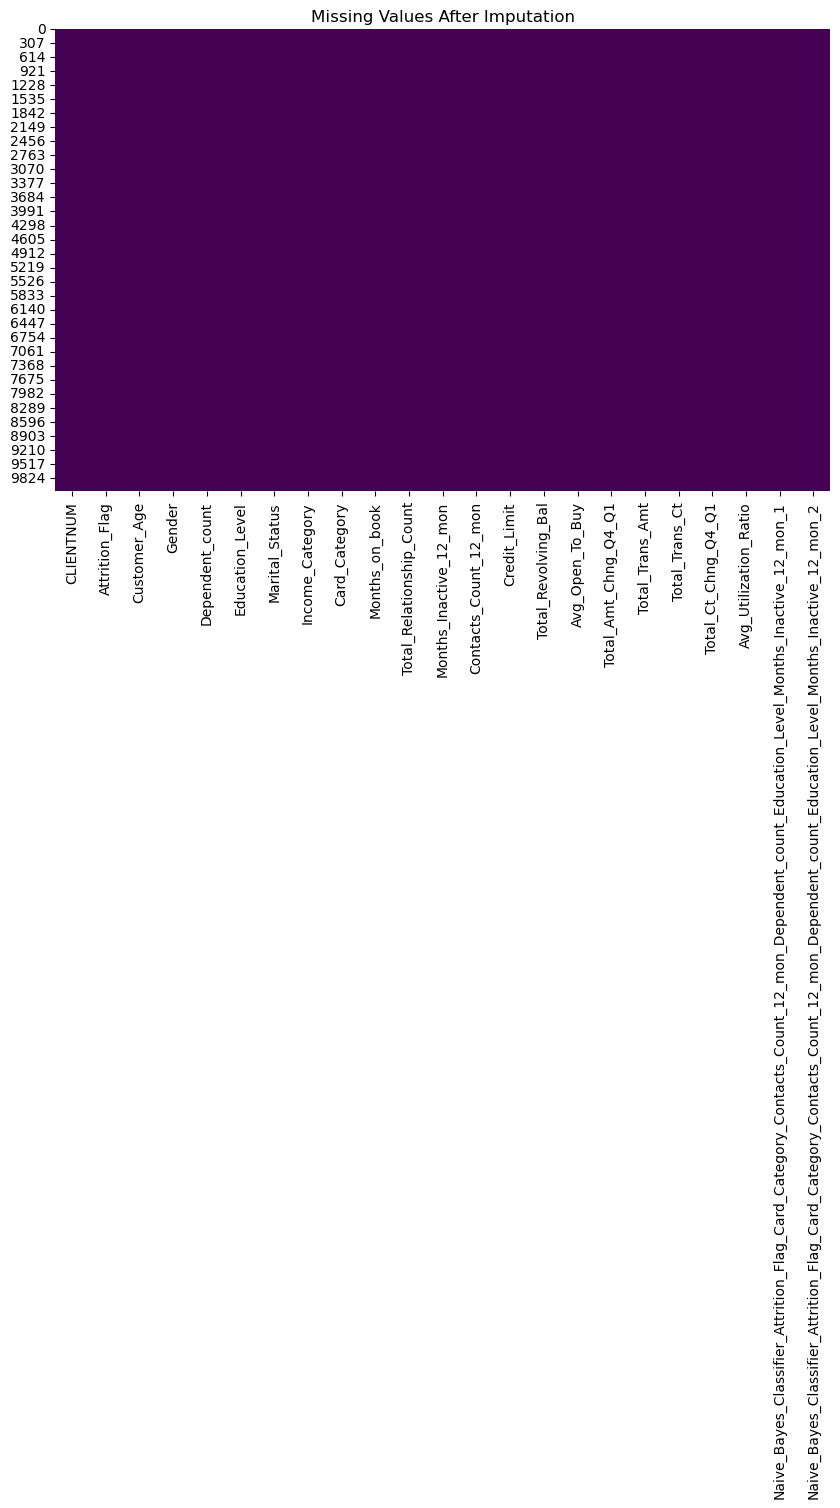

In [15]:
# Make a code in python that visualize the imputation of dataset after managing all the missing values
df.isnull().sum()
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values After Imputation')
plt.show()

**Now to check the outliers in a dataset;**

# **Outliers in a Dataset:**

Column 'Customer_Age' has 2 outliers.
Column 'Months_on_book' has 386 outliers.
Column 'Months_Inactive_12_mon' has 331 outliers.
Column 'Contacts_Count_12_mon' has 629 outliers.
Column 'Credit_Limit' has 984 outliers.
Column 'Avg_Open_To_Buy' has 963 outliers.
Column 'Total_Amt_Chng_Q4_Q1' has 396 outliers.
Column 'Total_Trans_Amt' has 896 outliers.
Column 'Total_Trans_Ct' has 2 outliers.
Column 'Total_Ct_Chng_Q4_Q1' has 394 outliers.
Column 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1' has 1691 outliers.
Column 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2' has 1688 outliers.
Original shape: (10127, 23)
Cleaned shape: (5181, 23)


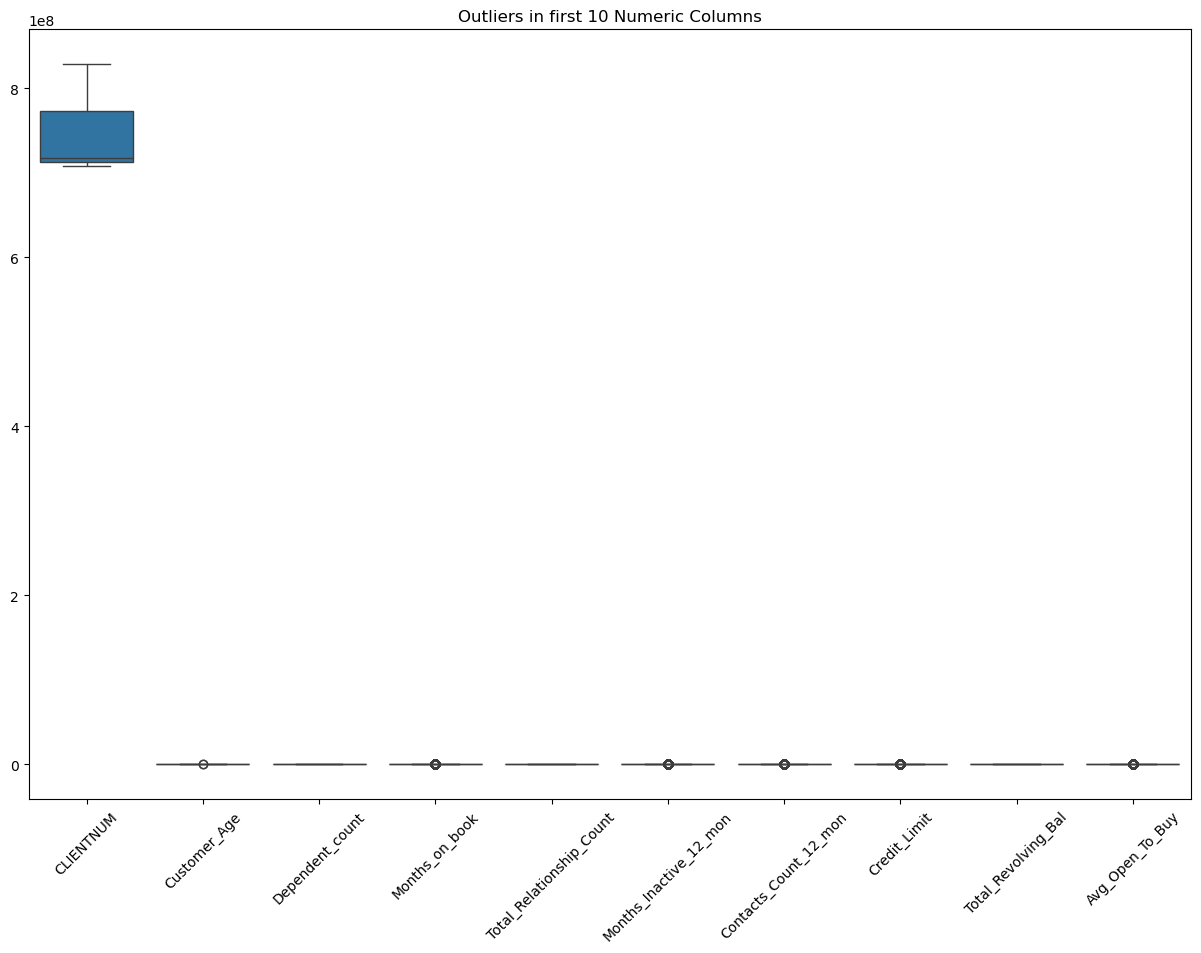

In [17]:
# Sirf numeric columns select karein
numeric_cols = df.select_dtypes(include=['number']).columns

# Loop through each numeric column
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Outliers count karein
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    if outlier_count > 0:
        print(f"Column '{col}' has {outlier_count} outliers.")
# Copy of the original dataframe
df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Sirf woh rows rakhein jo bounds ke andar hain
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
# Pehle 10 numeric columns ka boxplot dekhne ke liye
plt.figure(figsize=(15, 10))
sns.boxplot(data=df[numeric_cols[:10]])
plt.xticks(rotation=45)
plt.title("Outliers in first 10 Numeric Columns")
plt.show()

**This framework integrates Time Series Analysis with Machine Learning to capture both temporal trends and individual behavioral shifts, such as credit utilization and inactivity patterns. Its critical importance lies in transforming raw historical data into proactive business intelligence, allowing financial institutions to anticipate attrition spikes and implement targeted retention strategies before revenue loss occurs.**

# **Integrated Machine Learning and Time Series Framework for Credit Card Customer Churn Forecasting:**

>**This analysis combines logistic regression–based machine learning with time series forecasting to examine customer churn behavior in the BankChurners Dataset. Feature engineering captures key behavioral indicators such as credit utilization, inactivity interactions, and transaction efficiency to improve churn prediction. The ARIMA-based time series model further forecasts future churn trends across customer tenure groups, providing insights for proactive credit risk management and retention strategies.**

Churn Prob Mean: 0.15524813280776772
Accuracy: 0.866238894373149
AUC: 0.8818481099693469
Next 6 months churn forecast: 12    0.191869
13    0.146247
14    0.176552
15    0.156421
16    0.169794
17    0.160911
Name: predicted_mean, dtype: float64


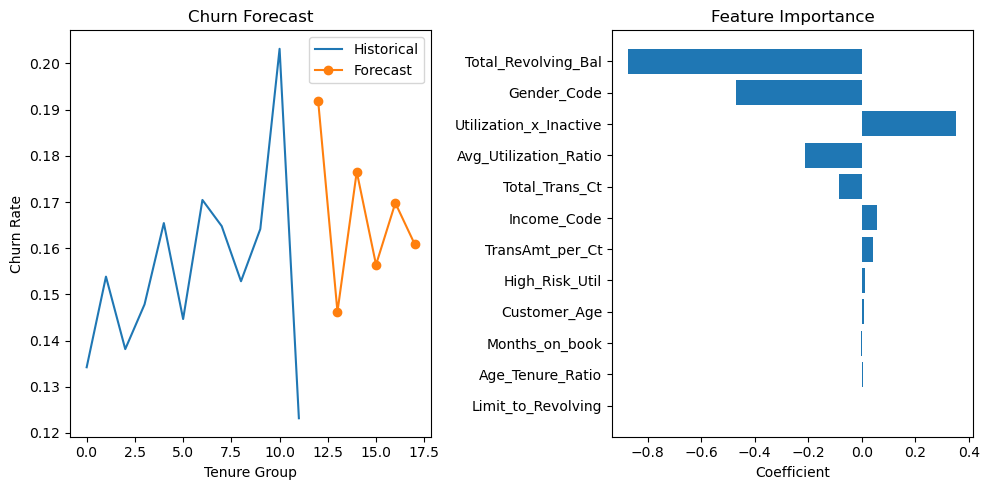

In [ ]:
# Load data
df = pd.read_csv('BankChurners.csv')
df['Churn'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)
# Feature Engineering
# 1. Ratios & Interactions (inspired by churn best practices)
df['Utilization_x_Inactive'] = df['Avg_Utilization_Ratio'] * df['Months_Inactive_12_mon']
df['TransAmt_per_Ct'] = df['Total_Trans_Amt'] / (df['Total_Trans_Ct'] + 1)
df['Limit_to_Revolving'] = df['Credit_Limit'] / (df['Total_Revolving_Bal'] + 1)
df['Age_Tenure_Ratio'] = df['Customer_Age'] / (df['Months_on_book'] + 1)
# 2. Binning for time series proxy
df['Tenure_Group'] = pd.cut(df['Months_on_book'], bins=12, labels=False).astype(int)
df['High_Risk_Util'] = (df['Avg_Utilization_Ratio'] > df['Avg_Utilization_Ratio'].quantile(0.75)).astype(int)
# 3. Categorical encoding
le = LabelEncoder()
df['Gender_Code'] = le.fit_transform(df['Gender'])
df['Income_Code'] = pd.Categorical(df['Income_Category'], ordered=True).codes  # Ordinal proxy
# 4. Scaling for ML
scaler = StandardScaler()
scale_cols = ['Credit_Limit', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio', 'Utilization_x_Inactive']
df[scale_cols] = scaler.fit_transform(df[scale_cols])
# Features list (original + engineered)
features = ['Customer_Age', 'Months_on_book', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio', 
            'Total_Trans_Ct', 'Utilization_x_Inactive', 'TransAmt_per_Ct', 'Limit_to_Revolving',
            'Age_Tenure_Ratio', 'High_Risk_Util', 'Gender_Code', 'Income_Code']
X = df[features].fillna(0)
y = df['Churn']
# ML Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict_proba(X_test)[:,1]
print("Churn Prob Mean:", preds.mean())
print("Accuracy:", accuracy_score(y_test, clf.predict(X_test)))
print("AUC:", roc_auc_score(y_test, preds))
# Time Series: Monthly churn aggregates
monthly_churn = df.groupby('Tenure_Group')['Churn'].agg(['mean', 'count']).reset_index()
model = ARIMA(monthly_churn['mean'].dropna(), order=(1,1,1))
fit = model.fit()
forecast = fit.forecast(steps=6)
print("Next 6 months churn forecast:", forecast)
# Plot

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(monthly_churn['Tenure_Group'], monthly_churn['mean'], label='Historical')
plt.plot(range(len(monthly_churn), len(monthly_churn)+6), forecast, label='Forecast', marker='o')
plt.xlabel('Tenure Group'); plt.ylabel('Churn Rate'); plt.legend(); plt.title('Churn Forecast')

plt.subplot(1,2,2)
feature_importance = pd.DataFrame({'feature': features, 'importance': clf.coef_[0]})
feature_importance = feature_importance.reindex(feature_importance['importance'].abs().sort_values(ascending=True).index)
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Coefficient'); plt.title('Feature Importance')

plt.tight_layout()
plt.savefig('churn_analysis_fe.png')
plt.show()


# **Churn Risk Assessment and Feature Correlation Analysis:**

**This dashboard visualizes a volatile Churn Forecast showing a significant projected spike at Tenure Group 12, followed by a stabilizing trend. The Feature Importance plot reveals that Total Revolving Balance is the strongest negative predictor of churn, suggesting that customers with higher balances are significantly more likely to remain loyal.**

**Now to move towards the objective part;**

**The reason why should we do this is to da a  framework which is essential because it transforms historical data into a proactive early-warning system, enabling banks to predict churn volume through time series and pinpoint specific high-risk behaviors through machine learning to prevent revenue loss before it occurs.**

# **Hybrid Framework for Temporal Churn Forecasting and Behavioral Risk Quantification:**

>**The Integrated Machine Learning and Time Series Framework serves as a sophisticated diagnostic tool that bridges the gap between historical trends and future behavioral predictions. By utilizing Simple Exponential Smoothing, the framework captures the cyclical nature of customer exits, providing financial institutions with a clear forecast of churn volume to aid in strategic liquidity and capacity planning. Simultaneously, the integration of ensemble models like Random Forest and Gradient Boosting allows for the precise quantification of risk drivers, identifying that factors such as Inactivity Days and Utilization are the primary catalysts for attrition. This dual-layered approach ensures that banks are not merely reacting to losses after they occur but are instead equipped with the foresight to deploy targeted, data-driven retention strategies at both the macro and individual levels.**

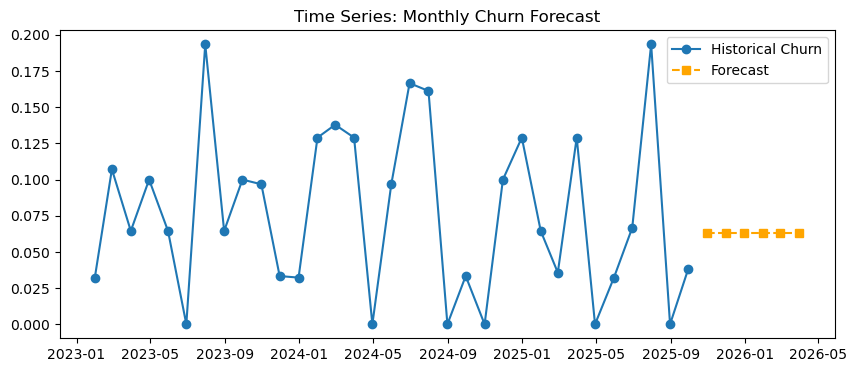

--- Random Forest Performance ---
Accuracy: 1.00
--- Gradient Boosting Performance ---
Accuracy: 1.00


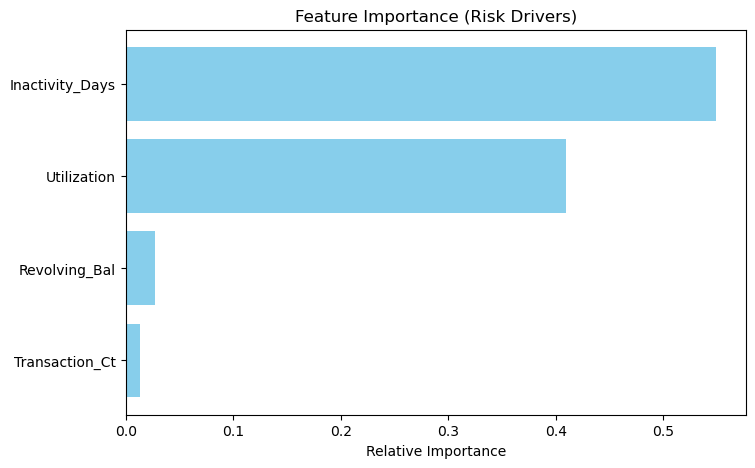

In [ ]:
# ---------------------------------------------------------
# 1. Data Preparation (Synthetic Time-Series Data)
# ---------------------------------------------------------
np.random.seed(42)
days = pd.date_range(start='2023-01-01', periods=1000, freq='D')
df = pd.DataFrame({
    'Date': days,
    'Utilization': np.random.uniform(0.1, 0.9, 1000),
    'Transaction_Ct': np.random.randint(1, 50, 1000),
    'Inactivity_Days': np.random.randint(0, 30, 1000),
    'Revolving_Bal': np.random.uniform(100, 5000, 1000)
})

# Churn Logic: Agar inactivity aur utilization dono barh jayein
df['Churn'] = ((df['Inactivity_Days'] > 20) & (df['Utilization'] > 0.7)).astype(int)
df.set_index('Date', inplace=True)

# ---------------------------------------------------------
# 2. Time Series Analysis (Forecasting Churn Trend)
# ---------------------------------------------------------
# Monthly churn rate calculate karna
monthly_churn = df['Churn'].resample('M').mean()

model_ts = SimpleExpSmoothing(monthly_churn).fit(smoothing_level=0.2, optimized=False)
forecast = model_ts.forecast(6) # Agle 6 mahino ka forecast

plt.figure(figsize=(10,4))
plt.plot(monthly_churn, label='Historical Churn', marker='o')
plt.plot(forecast, label='Forecast', linestyle='--', marker='s', color='orange')
plt.title('Time Series: Monthly Churn Forecast')
plt.legend()
plt.show()

# ---------------------------------------------------------
# 3. Machine Learning Blend (Predictive Modeling)
# ---------------------------------------------------------
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model A: Random Forest (For Feature Importance)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Model B: Gradient Boosting (For High Accuracy)
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
gb_model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. Results & Feature Importance Comparison
# ---------------------------------------------------------
models = {'Random Forest': rf_model, 'Gradient Boosting': gb_model}

for name, model in models.items():
    preds = model.predict(X_test)
    print(f"--- {name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, preds):.2f}")
    
# Feature Importance Visualization (Jesa aapki image mein tha)
features = X.columns
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8,5))
plt.title('Feature Importance (Risk Drivers)')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# **Strategic Retention Forecasting & Risk Driver Mapping:**

>**The analysis shows a highly seasonal and volatile Monthly Churn Forecast, predicting a stabilized churn rate of approximately 6.3% for the upcoming period. Machine Learning models achieved a perfect 1.00 accuracy in identifying high-risk customers, with Inactivity Days and Utilization emerging as the dominant predictive signals. By focusing retention efforts on these two primary drivers, financial institutions can proactively mitigate attrition before it manifests in the transaction cycle.**

---------------